In [1]:

import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

/Users/krishrohilla/Desktop/MindzKonnected/Tutorial/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [3]:

from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

In [4]:
## Define the state
class AgentState(MessagesState):
    next_agent:str #ehich agent should go next 

In [ ]:
# Create simple tools
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [6]:
from langchain.chat_models import init_chat_model

llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x118388d10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x118439ed0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [ ]:
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""
    
    messages = state["messages"]
    
   
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")

    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [ ]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""
    
    messages = state["messages"]
    
    
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")
    
   
    response = llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

In [ ]:
# Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response
    
    return state

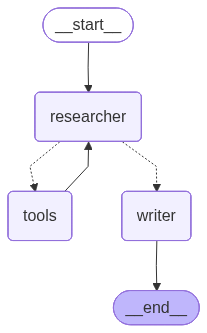

In [15]:

def route_after_researcher(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "writer"

workflow = StateGraph(AgentState) 

workflow.add_node("researcher", researcher_agent)
workflow.add_node("tools", execute_tools)  
workflow.add_node("writer", writer_agent)

workflow.set_entry_point("researcher")

workflow.add_conditional_edges(
    "researcher",
    route_after_researcher,
    {
        "tools": "tools",
        "writer": "writer"
    }
)

workflow.add_edge("tools", "researcher")

workflow.add_edge("writer", END)
final_workflow = workflow.compile()
final_workflow


In [16]:
response=final_workflow.invoke({"messages":"Reasearch about the usecase of agentic ai in business"})
response

/var/folders/lb/1wnz8jsx11gbw_8n15b7gcbc0000gn/T/ipykernel_45365/3356794159.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results=3)


{'messages': [HumanMessage(content='Reasearch about the usecase of agentic ai in business', additional_kwargs={}, response_metadata={}, id='481688fd-90a3-43b1-8d7a-5ccab8966b29'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '106dg6q0z', 'function': {'arguments': '{"query":"agentic AI in business use case"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 243, 'total_tokens': 263, 'completion_time': 0.038871199, 'completion_tokens_details': None, 'prompt_time': 0.020705875, 'prompt_tokens_details': None, 'queue_time': 0.166227742, 'total_time': 0.059577074}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb6a9-da53-7d51-9995-b9b84ac288a8-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'agentic AI in business use case'}, 'id': '106dg6q0

In [18]:
response["messages"][-2].content

'Based on the search results, agentic AI has various use cases in business, including:\n\n1. Automating core finance operations, such as expense reporting, approvals, and compliance checks.\n2. Streamlining high-volume, rules-driven processes in finance, such as invoice processing and accounts payable.\n3. Improving operational efficiency and reducing costs in finance by automating tasks and improving data-driven decision-making.\n4. Enhancing HR operations and employee support by automating routine administrative processes and providing real-time, personalized support.\n5. Transforming IT support by proactively identifying and resolving issues before they escalate.\n6. Automating IT support and service management by handling routine tasks and integrating with various enterprise systems to diagnose and resolve complex technical issues.\n7. Improving education operations by automating admissions, financial aid, and benefits administration.\n8. Enhancing cybersecurity by providing real-t

# supervise Multi Ai Agent Architecture

In [19]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

In [20]:
class SupervisorState(MessagesState):
    """State for the multi-agent system"""
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""

In [21]:
from langchain_core.prompts import ChatPromptTemplate
def create_supervisor_chain():
    """Creates the supervisor decision chain"""
    
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:
        
1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights  
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
"""),
        ("human", "{task}")
    ])
    
    return supervisor_prompt | llm

In [22]:
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""
    
    messages = state["messages"]
    task = messages[-1].content if messages else "No task"
    
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))
    
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report
    })
    
    decision_text = decision.content.strip().lower()
    print(decision_text)
    
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = " Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = " Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = " Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = " Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg = " Supervisor: Task seems complete."
    
    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

In [30]:
def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""
    
    task = state.get("current_task", "research topic")
    
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies
    
    Be concise but thorough."""
    
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content
    
    agent_message = f" Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }

In [31]:
def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""
    
    research_data = state.get("research_data", "")
    task = state.get("current_task", "")
    
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}"""
    
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content
    
    agent_message = f" Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:400]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [38]:
def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""
    
    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")
    
    writing_prompt = f"""As a professional writer, create an executive report based on:

Task: {task}

Research Findings:
{research_data[:1000]}

Analysis:
{analysis[:1000]}

Create a well-structured report with:
1. Executive Summary
2. Key Findings  
3. Analysis & Insights
4. Recommendations
5. Conclusion

Keep it professional and concise."""
    
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content
    
    final_report = f"""
 FINAL REPORT
{'='*50}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Topic: {task}
{'='*50}

{report}

{'='*50}
Report compiled by Multi-Agent AI System powered by Groq
"""
    return {
        "messages": [AIMessage(content=f" Writer: Report complete! See below for the full document.")],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }

In [39]:
def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""
    
    next_agent = state.get("next_agent", "supervisor")
    
    if next_agent == "end" or state.get("task_complete", False):
        return END
        
    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent
        
    return "supervisor"
    

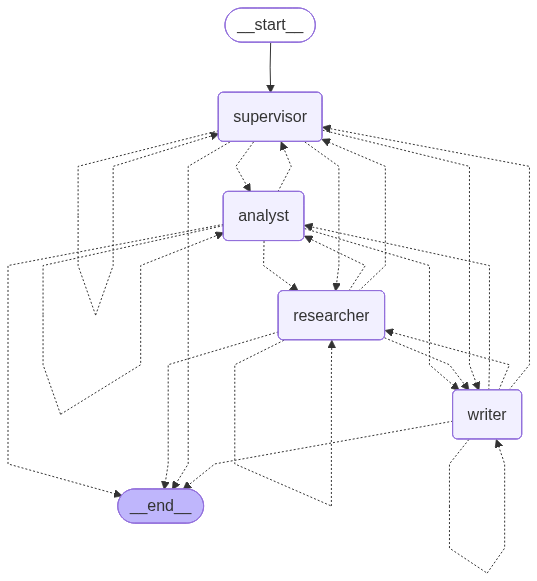

In [40]:
workflow = StateGraph(SupervisorState)

workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

workflow.set_entry_point("supervisor")

for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END
        }
    )

graph=workflow.compile()
graph

In [41]:
response = graph.invoke({
    "messages": [
        HumanMessage(content="What are the benefits and risks of AI in healthcare?")
    ]
})


researcher
analyst
writer


In [42]:
response

{'messages': [HumanMessage(content='What are the benefits and risks of AI in healthcare?', additional_kwargs={}, response_metadata={}, id='1909a5e5-92c1-41e0-b02b-2a94cde54672'),
  AIMessage(content=" Supervisor: Let's start with research. Assigning to Researcher...", additional_kwargs={}, response_metadata={}, id='8ab47261-96e2-486a-bd5c-7463eb605780', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content=" Researcher: I've completed the research on 'What are the benefits and risks of AI in healthcare?'.\n\nKey findings:\n**Benefits and Risks of AI in Healthcare: A Comprehensive Analysis**\n\n**1. Key Facts and Background**\n\nArtificial Intelligence (AI) in healthcare refers to the application of algorithms and machine learning techniques to analyze and interpret medical data, improve patient outcomes, and enhance the overall healthcare experience. AI has the potential to revolutionize healthcare by providing personalized medicine, streamlining clinical workflows, and reducing m

In [43]:
print(response["final_report"])



 FINAL REPORT
Generated: 2026-06-11 20:54
Topic:  Analyst: I've completed the analysis.

Top insights:
**Key Insights and Patterns:**

1. **AI has the potential to revolutionize healthcare**: The application of AI in healthcare can lead to improved patient outcomes, streamlined clinical workflows, and reduced medical errors.
2. **Personalized medicine is a key benefit**: AI-powered precision medicine can provide personalized treatment plans based on patients' genetic profiles, medical histories, an...

**Executive Report: The Future of AI in Healthcare**

**Executive Summary**

This report provides a comprehensive analysis of the benefits and risks of Artificial Intelligence (AI) in healthcare. Our research reveals that AI has the potential to revolutionize healthcare by providing personalized medicine, streamlining clinical workflows, and reducing medical errors. Key findings highlight the widespread adoption of AI in healthcare organizations, improved diagnostic accuracy, and growin